# Spam Email Classifier

## Project Description

This project builds a machine learning model that classifies text messages as either **spam** or **ham**. The model uses natural language processing techniques to convert raw message text into numerical features, then applies a Naive Bayes classifier to predict whether a message is unwanted spam or a normal message.

## Objective

The main objective of this project is to automatically detect spam messages with high accuracy and evaluate the model using standard classification metrics.

## Dataset

The project uses the SMS Spam Collection Dataset, which contains 5,572 labeled messages. Each message is marked as either `ham` for normal messages or `spam` for unwanted messages.

## Technologies Used

- Python
- Pandas
- Scikit-learn
- TF-IDF Vectorizer
- Multinomial Naive Bayes
- Matplotlib and Seaborn

## Project Workflow

1. Load and clean the spam dataset.
2. Check data quality, missing values, and duplicate messages.
3. Perform exploratory data analysis on class balance and message length.
4. Create useful text-based features.
5. Preprocess raw message text for machine learning.
6. Convert labels into numerical values.
7. Split the data into training and testing sets.
8. Convert cleaned text messages into TF-IDF features.
9. Train and evaluate a Multinomial Naive Bayes classifier.

## Results

The trained model achieved strong performance on the test data, showing that TF-IDF combined with Naive Bayes is an effective approach for spam message classification.

## Learning Outcome

Through this project, I learned how to preprocess text data, transform messages into machine-readable features, train a classification model, and evaluate model performance using meaningful metrics.


## Step 1: Import Required Libraries

In this cell, I import the Python libraries needed for the full project. Pandas is used for loading and preparing the dataset, Scikit-learn is used for splitting data, converting text into features, training the Naive Bayes model, and evaluating performance, while Matplotlib and Seaborn are used for visualization.


In [4]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load and Prepare the Dataset

Here, I load the spam dataset from the CSV file. The original dataset contains extra columns, so I keep only the label column and the message text column. I rename them to `label` and `message` to make the data easier to understand throughout the notebook.


In [6]:
df = pd.read_csv(
	'./spam-classifier dataset/spam.csv',
	encoding='latin-1',
	usecols=[0, 1],
	engine='python',
	on_bad_lines='skip'
)

df.columns = ['label', 'message']

print("Dataset shape:", df.shape)
print("First 5 rows of the dataset:")
print(df.head())

Dataset shape: (6530, 2)
First 5 rows of the dataset:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## Step 3: Data Quality Check

Before building the model, I check whether the dataset has missing values or duplicate messages. Missing values can break preprocessing, and duplicates can make evaluation less honest because the same message may appear more than once.


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

duplicate_count = df.duplicated(subset='message').sum()
print("\nDuplicate messages:", duplicate_count)

df = df.drop_duplicates(subset='message').reset_index(drop=True)
print("Dataset shape after removing duplicates:", df.shape)

Missing values in each column:
label      0
message    0
dtype: int64

Duplicate messages: 405
Dataset shape after removing duplicates: (6125, 2)


## Step 4: Check the Label Distribution

This cell checks how many messages are labeled as `ham` and how many are labeled as `spam`. This is important because spam datasets are often imbalanced, meaning there are usually many more normal messages than spam messages.


In [8]:
print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
ham     4995
spam    1130
Name: count, dtype: int64


## Step 5: Visualize Class Distribution

This chart gives a quick visual comparison between ham and spam messages. It helps confirm that the dataset is imbalanced, which is common in spam detection problems.


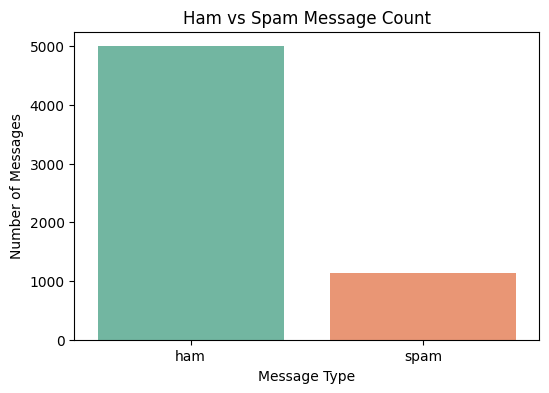

In [30]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False)
plt.title('Ham vs Spam Message Count')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.savefig('images/message_count.png')
plt.show()

## Step 6: Create Basic Message Features

For EDA and feature understanding, I create extra columns from each message. These include message length, word count, number of digits, number of punctuation symbols, and number of stop words. These features help reveal how spam messages differ from normal messages.


In [10]:
df['message_length'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()
df['digit_count'] = df['message'].str.count(r'\d')
df['punctuation_count'] = df['message'].str.count(r'[^\w\s]')
df['stop_word_count'] = df['message'].str.lower().str.split().apply(
    lambda words: sum(word in ENGLISH_STOP_WORDS for word in words)
)

df[['label', 'message_length', 'word_count', 'digit_count', 'punctuation_count', 'stop_word_count']].head()

,label,message_length,word_count,digit_count,punctuation_count,stop_word_count
0,ham,111,20,0,9,5
1,ham,29,6,0,6,0
2,spam,155,28,25,6,6
3,ham,49,11,0,6,3
4,ham,61,13,0,2,7


## Step 7: Compare Ham and Spam Message Patterns

In this EDA step, I compare average message statistics for ham and spam messages. Spam messages often contain more promotional words, numbers, punctuation, or longer text, so these comparisons help explain the behavior of the classifier.


       message_length  word_count  digit_count  punctuation_count  \
label                                                               
ham         73.786787   14.074875      0.87047           4.041241   
spam       128.206195   19.568142     11.69646           5.996460   

       stop_word_count  
label                   
ham           5.719920  
spam          4.770796  


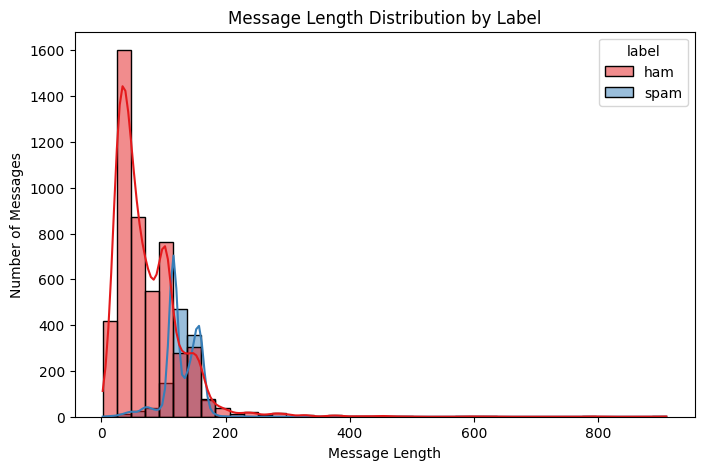

In [29]:
feature_summary = df.groupby('label')[['message_length', 'word_count', 'digit_count', 'punctuation_count', 'stop_word_count']].mean()
print(feature_summary)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=40, kde=True, palette='Set1')
plt.title('Message Length Distribution by Label')
plt.xlabel('Message Length')
plt.ylabel('Number of Messages')
plt.savefig('images/message_length_distribution.png')
plt.show()

## Step 8: Text Preprocessing

Before converting text into numerical features, I clean each message by converting it to lowercase, removing URLs, removing numbers, removing punctuation, and removing extra spaces. This creates a cleaner version of the message for TF-IDF vectorization.


In [12]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## Step 9: Encode Text Labels

Machine learning models work with numbers, not text labels. In this step, I convert `ham` into `0` and `spam` into `1`, so the classifier can learn from the target values.


In [13]:
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

## Step 10: Separate Features and Target

In this cell, I separate the input data from the output labels. `X` contains the cleaned message text that the model will learn from, and `y` contains the encoded label that tells the model whether each message is ham or spam.


In [14]:
X = df['clean_message']
y = df['label_encoded']

## Step 11: Split Data into Training and Testing Sets

I split the dataset into training and testing parts. The training data is used to teach the model, while the testing data is kept separate so I can check how well the model performs on messages it has not seen before.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train}")
print(f"Testing samples: {X_test}")


Training samples: 1780                             are you comingdown later
2859    yeah no probs last night is obviously catching...
5719    spamex promotional alert number claiming rewar...
4365                             i m leaving my house now
4546                              lol oops sorry have fun
                              ...                        
3772    eek that s a lot of time especially since amer...
5191    congratulations you ve won a free cruise to th...
5226    hamex regular class message number about notes...
5390    hamex regular class message number about notes...
860     u have a secret admirer who is looking make co...
Name: clean_message, Length: 4900, dtype: object
Testing samples: 2922    deep sigh i miss you i am really surprised you...
1170    thanks for understanding i ve been trying to t...
2516                          no way i m going back there
1820             i love your ass do you enjoy doggy style
3806                      i was slept that ti

## Step 12: Convert Text into TF-IDF Features

The model cannot directly understand raw sentences, so I use TF-IDF vectorization to convert each cleaned message into numerical features. TF-IDF gives more importance to useful words and reduces the impact of common words that do not help much with classification.


In [16]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Step 13: Train the Naive Bayes Model

In this step, I train a Multinomial Naive Bayes model using the TF-IDF features. Naive Bayes is commonly used for text classification because it works well with word-frequency based features and is fast to train.


In [17]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Step 14: Make Predictions on Test Data

After training the model, I use it to predict labels for the test messages. These predictions are later compared with the real labels to measure how accurately the model performs.


In [18]:
y_pred = model.predict(X_test_tfidf)

## Step 15: Evaluate Model Performance

This cell calculates the main classification metrics: accuracy, precision, recall, and F1-score. These metrics help explain not only how many predictions were correct, but also how well the model identifies spam messages specifically.


In [19]:
accuracy= accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Ham', 'Spam'])

print(f"\n Accuracy: {accuracy:.4f} %")
print(f" Precision: {precision:.4f} %")
print(f" Recall: {recall:.4f} %")
print(f" F1-Score: {f1:.4f} %")
print("\n Classification Report:")
print(report)


 Accuracy: 0.9690 %
 Precision: 1.0000 %
 Recall: 0.8397 %
 F1-Score: 0.9128 %

 Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       988
        Spam       1.00      0.84      0.91       237

    accuracy                           0.97      1225
   macro avg       0.98      0.92      0.95      1225
weighted avg       0.97      0.97      0.97      1225



## Step 16: Visualize the Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for both ham and spam messages. This makes it easier to see where the model is performing well and where it is making mistakes.


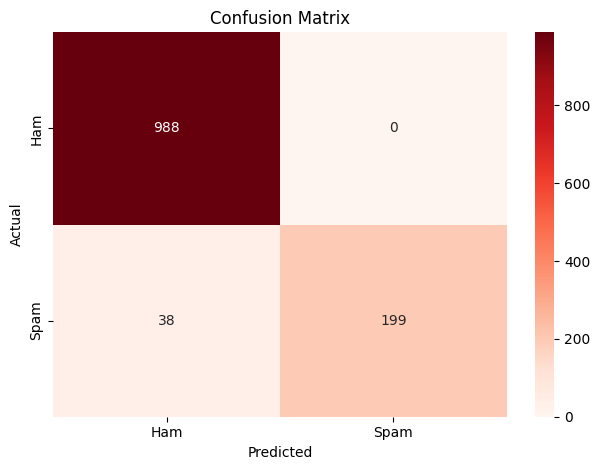

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./spam-classifier/images/confusion_matrix.png')
plt.show()

## Step 17: Create a Custom Prediction Function

This function allows me to test any new message. It first converts the message into TF-IDF features using the same vectorizer, then predicts whether the message is spam or ham and displays the model confidence.


In [21]:
def predict_spam(message):
    cleaned_message = clean_text(message)
    vec = vectorizer.transform([cleaned_message])
    result = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "🚨 SPAM" if result == 1 else "✅ HAM (Not Spam)"
    print(f"\nMessage : {message}")
    print(f"Result  : {label}")
    print(f"Confidence → Ham: {prob[0]:.2%} | Spam: {prob[1]:.2%}")

## Step 18: Test the Model with Example Messages

Finally, I test the project with sample messages. These examples show how the trained classifier behaves on both promotional spam-like messages and normal conversation messages.


In [22]:
predict_spam("Congratulations! You've won a free iPhone. Click here now!")
predict_spam("Hey, are we still meeting tomorrow at 3pm?")
predict_spam("URGENT: Your bank account has been suspended. Verify now.")


Message : Congratulations! You've won a free iPhone. Click here now!
Result  : 🚨 SPAM
Confidence → Ham: 38.59% | Spam: 61.41%

Message : Hey, are we still meeting tomorrow at 3pm?
Result  : ✅ HAM (Not Spam)
Confidence → Ham: 98.56% | Spam: 1.44%

Message : URGENT: Your bank account has been suspended. Verify now.
Result  : 🚨 SPAM
Confidence → Ham: 30.19% | Spam: 69.81%


In [25]:
import pickle
pickle.dump(model, open('models/model.pkl', 'wb'))
pickle.dump(vectorizer, open('models/vectorizer.pkl', 'wb'))